# Práctica 2 – Análisis estadístico de señales


**Universidad de Antioquia - Facultad de Ingeniería - Bioingeniería - Laboratorio Bioseñales y Sistemas**

- Mariana Paulina Vargas Velez
- Sofia Cedeño Vargas


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

In [16]:
DATA_DIR =Path(r"C:\Users\Lenovo\Desktop\Lab Bioseñales\biosenales_2026\practica_02\Parte2\ECGData")
DIAGNOSTICS_PATH = Path(r"C:\Users\Lenovo\Desktop\Lab Bioseñales\biosenales_2026\practica_02\Parte2\Diagnostics.xlsx")  # archivo de metadatos/etiquetas

assert os.path.exists(DIAGNOSTICS_PATH), "No se encontró Diagnostics.xlsx, ajuste la ruta"
assert os.path.isdir(DATA_DIR), "No se encontró la carpeta ECGData, ajuste la ruta"

## 1. Exploración y descripción de la base de datos

### 1.1 Carga de metadatos

In [17]:
diag = pd.read_excel(DIAGNOSTICS_PATH)
diag.columns = [c.strip() for c in diag.columns]
print(f"Dimensiones de la tabla de metadatos: {diag.shape}")
diag.head()

Dimensiones de la tabla de metadatos: (10646, 16)


,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354


Los nombres exactos de columna pueden variar ligeramente entre versiones del archivo, por lo que se detectan de forma flexible (por palabra clave) en lugar de asumir un nombre fijo.

In [18]:
def find_col(df, keywords):
    """Retorna la primera columna cuyo nombre (en minúsculas) contenga alguna de las keywords."""
    for col in df.columns:
        low = col.lower()
        if any(k in low for k in keywords):
            return col
    return None

col_filename = find_col(diag, ["filename", "file_name", "record"])
col_rhythm   = find_col(diag, ["rhythm"])
col_age      = find_col(diag, ["age"])
col_gender   = find_col(diag, ["gender", "sex"])

print("Columna de nombre de archivo :", col_filename)
print("Columna de ritmo/arritmia    :", col_rhythm)
print("Columna de edad              :", col_age)
print("Columna de género            :", col_gender)

Columna de nombre de archivo : FileName
Columna de ritmo/arritmia    : Rhythm
Columna de edad              : PatientAge
Columna de género            : Gender


### 1.2 Número total de registros y sujetos

In [19]:
n_records = diag.shape[0]
print(f"Número total de registros: {n_records}")
print("En ChapmanECG cada registro corresponde a un único paciente, "
      "por lo que el número de sujetos es igual al número de registros.")

Número total de registros: 10646
En ChapmanECG cada registro corresponde a un único paciente, por lo que el número de sujetos es igual al número de registros.


### 1.3 Tipos de arritmias/clases y número de registros por grupo

In [20]:
rhythm_counts = diag[col_rhythm].value_counts().sort_values(ascending=False)

tabla_ritmos = rhythm_counts.rename("N_registros").to_frame()
tabla_ritmos["Porcentaje (%)"] = (tabla_ritmos["N_registros"] / n_records * 100).round(2)
tabla_ritmos

,N_registros,Porcentaje (%)
Rhythm,,
SB,3889,36.53
SR,1826,17.15
AFIB,1780,16.72
ST,1568,14.73
SVT,587,5.51
AF,445,4.18
SA,399,3.75
AT,121,1.14
AVNRT,16,0.15


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26636\2213155585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rhythm_counts.index, y=rhythm_counts.values, palette="viridis")


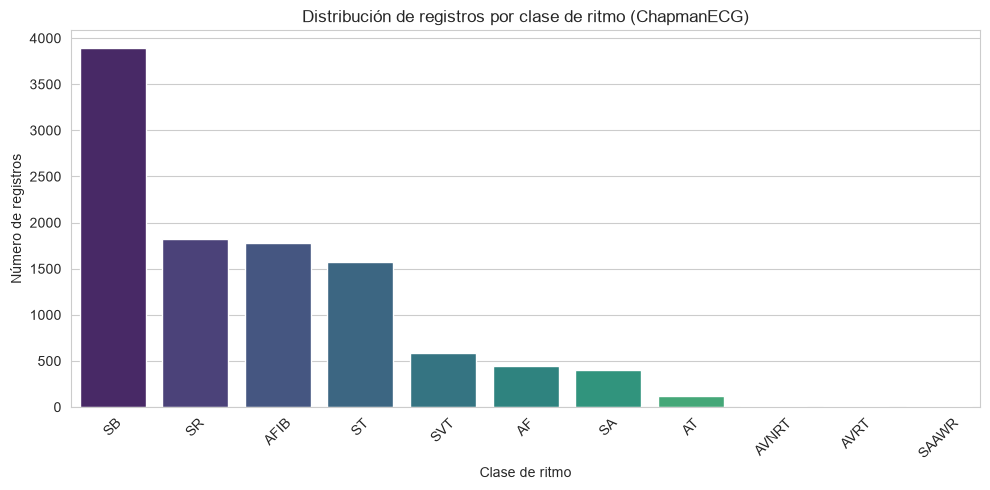

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x=rhythm_counts.index, y=rhythm_counts.values, palette="viridis")
plt.ylabel("Número de registros")
plt.xlabel("Clase de ritmo")
plt.title("Distribución de registros por clase de ritmo (ChapmanECG)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Significado de los códigos de ritmo** (11 clases definidas por los expertos que etiquetaron la base de datos):

| Código | Ritmo |
|---|---|
| SB | Bradicardia sinusal |
| SR | Ritmo sinusal (normal) |
| AFIB | Fibrilación auricular |
| ST | Taquicardia sinusal |
| SVT | Taquicardia supraventricular |
| AF | Flutter (aleteo) auricular |
| SA | Arritmia sinusal (irregularidad sinusal) |
| AT | Taquicardia auricular |
| AVNRT | Taquicardia por reentrada nodal AV |
| AVRT | Taquicardia por reentrada AV |
| SAAWR | Ritmo sinusal con marcapasos auricular errante |

Se observa un marcado desbalance de clases: la bradicardia sinusal (SB) y el ritmo sinusal (SR) concentran la mayor parte de los registros, mientras que clases como AVNRT, AVRT y SAAWR tienen muy pocos casos (menos de 20 registros cada una). Este desbalance debe tenerse en cuenta al seleccionar y comparar grupos en el análisis estadístico.

### 1.4 Canales disponibles y derivaciones

In [22]:
# Se toma un registro de ejemplo para inspeccionar la estructura de la señal
sample_name = diag[col_filename].iloc[0]
sample_name = sample_name if str(sample_name).endswith(".csv") else f"{sample_name}.csv"
sample_path = os.path.join(DATA_DIR, sample_name)

sample_signal = pd.read_csv(sample_path, header=None)
print("Forma de la señal de ejemplo (muestras x canales):", sample_signal.shape)

Forma de la señal de ejemplo (muestras x canales): (5001, 12)


In [23]:
# Orden estándar de las 12 derivaciones en las que se entregan las señales de ChapmanECG
lead_names = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]
print(f"Número de canales/derivaciones: {sample_signal.shape[1]}")
print("Derivaciones:", lead_names)

Número de canales/derivaciones: 12
Derivaciones: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


### 1.5 Frecuencia de muestreo y duración de los registros

In [24]:
fs = 500  # Hz — frecuencia de muestreo reportada para ChapmanECG
n_samples = sample_signal.shape[0]
duration_s = n_samples / fs

print(f"Frecuencia de muestreo : {fs} Hz")
print(f"Muestras por registro  : {n_samples}")
print(f"Duración por registro  : {duration_s:.1f} s")

Frecuencia de muestreo : 500 Hz
Muestras por registro  : 5001
Duración por registro  : 10.0 s


### 1.6 Resumen general

In [25]:
resumen = pd.DataFrame({
    "Característica": ["Registros totales", "Sujetos", "Clases de ritmo",
                       "Canales/derivaciones", "Frecuencia de muestreo", "Duración por registro"],
    "Valor": [n_records, n_records, diag[col_rhythm].nunique(),
              sample_signal.shape[1], f"{fs} Hz", f"{duration_s:.1f} s"]
})
resumen

,Característica,Valor
0,Registros totales,10646
1,Sujetos,10646
2,Clases de ritmo,11
3,Canales/derivaciones,12
4,Frecuencia de muestreo,500 Hz
5,Duración por registro,10.0 s


### Demografía de los sujetos

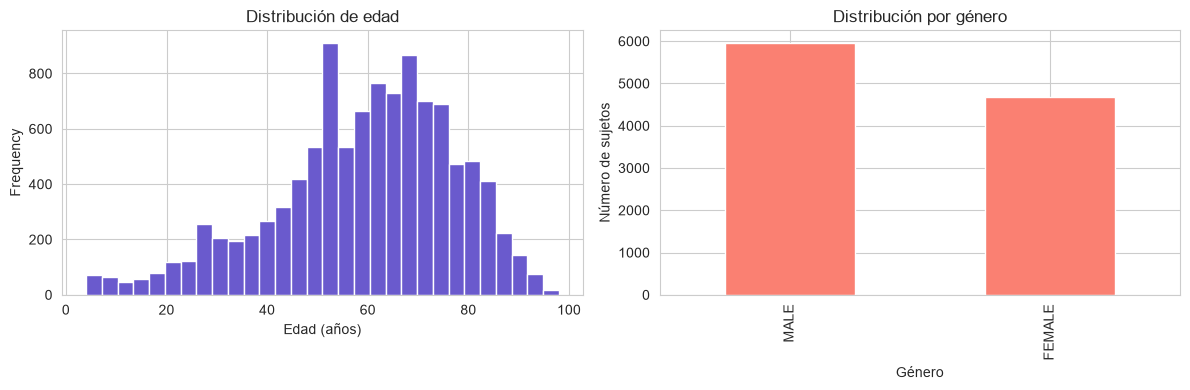

In [26]:
if col_age is not None and col_gender is not None:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    diag[col_age].dropna().plot(kind="hist", bins=30, ax=axs[0], color="slateblue")
    axs[0].set_title("Distribución de edad")
    axs[0].set_xlabel("Edad (años)")

    diag[col_gender].value_counts().plot(kind="bar", ax=axs[1], color="salmon")
    axs[1].set_title("Distribución por género")
    axs[1].set_xlabel("Género")
    axs[1].set_ylabel("Número de sujetos")

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas de edad/género en el archivo de metadatos.")

## 2. Visualización y caracterización de las señales

Se seleccionan dos registros correspondientes a dos tipos de arritmia distintos para compararlos: **fibrilación auricular (AFIB)** y **bradicardia sinusal (SB)**. Ambas son relativamente frecuentes en la base de datos, lo que facilita encontrar ejemplos, y presentan características electrocardiográficas claramente diferenciables.

### 2.1 Breve consulta de las arritmias seleccionadas

**Fibrilación auricular (AFIB).** Es la arritmia sostenida más frecuente en la práctica clínica. Se origina por una activación eléctrica auricular desorganizada y caótica, proveniente de múltiples focos, que reemplaza la actividad sinusal normal. En el ECG se manifiesta por la ausencia de ondas P discretas (en su lugar aparecen ondulaciones irregulares de la línea de base, llamadas ondas f) y por una respuesta ventricular "irregularmente irregular", es decir, con intervalos R-R que varían de forma aleatoria de un latido a otro. Se asocia a un mayor riesgo de formación de trombos auriculares y eventos tromboembólicos (como el accidente cerebrovascular).

**Bradicardia sinusal (SB).** Es un ritmo que se origina en el nodo sinusal (por lo tanto conserva ondas P de morfología normal y una relación P-QRS 1:1, con intervalo PR normal), pero con una frecuencia cardiaca menor a 60 latidos por minuto. El ritmo es regular. Puede ser un hallazgo fisiológico (por ejemplo, en deportistas entrenados o durante el sueño) o estar asociado a disfunción del nodo sinusal, hipotiroidismo, hipotermia o al efecto de ciertos fármacos (betabloqueadores, digoxina, entre otros).

In [27]:
def get_record(rhythm_code, index=0):
    """Obtiene la señal (n_muestras x 12) y los metadatos del registro `index`
    correspondiente a la clase de ritmo `rhythm_code`."""
    subset = diag[diag[col_rhythm] == rhythm_code].reset_index(drop=True)
    if subset.empty:
        raise ValueError(f"No se encontraron registros para la clase {rhythm_code}")
    fname = subset.loc[index, col_filename]
    fname = fname if str(fname).endswith(".csv") else f"{fname}.csv"
    path = os.path.join(DATA_DIR, fname)
    sig = pd.read_csv(path, header=None).values  # (n_muestras, 12)
    return sig, subset.loc[index]

rhythm_A, label_A = "AFIB", "Fibrilación auricular"
rhythm_B, label_B = "SB",   "Bradicardia sinusal"

sig_A, meta_A = get_record(rhythm_A, index=0)
sig_B, meta_B = get_record(rhythm_B, index=0)

print(f"Registro A ({label_A}):", meta_A[col_filename])
print(f"Registro B ({label_B}):", meta_B[col_filename])

Registro A (Fibrilación auricular): MUSE_20180113_171327_27000
Registro B (Bradicardia sinusal): MUSE_20180112_073319_29000


### 2.2 Visualización de la señal completa (10 s, derivación II)

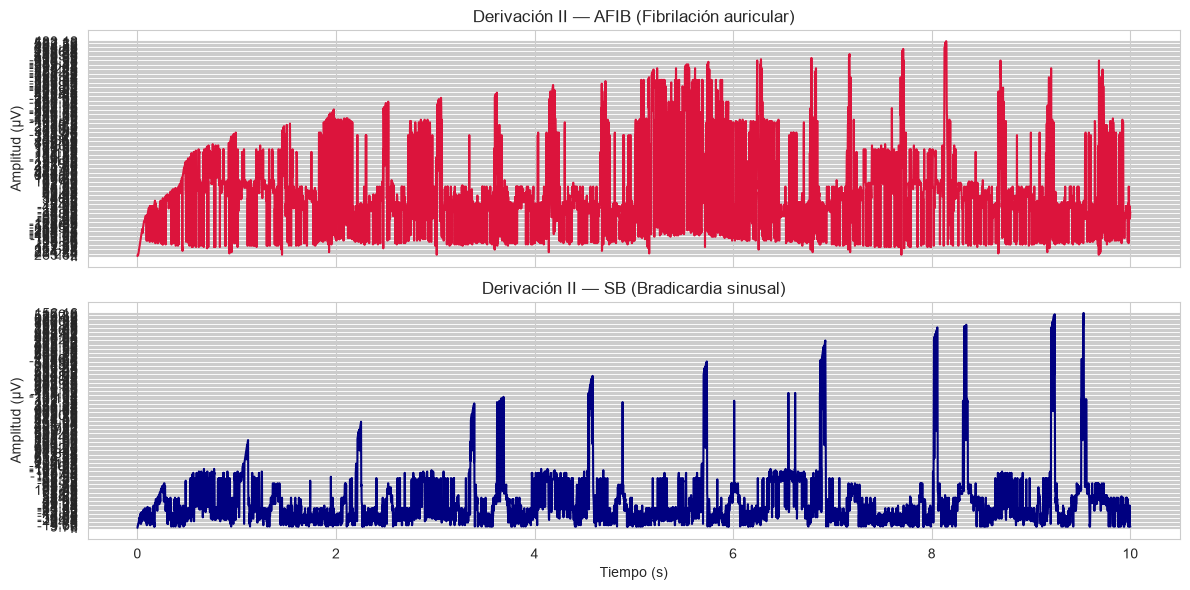

In [28]:
lead_idx = lead_names.index("II")
t = np.arange(n_samples) / fs

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t, sig_A[:, lead_idx], color="crimson")
axs[0].set_title(f"Derivación II — {rhythm_A} ({label_A})")
axs[0].set_ylabel("Amplitud (µV)")

axs[1].plot(t, sig_B[:, lead_idx], color="navy")
axs[1].set_title(f"Derivación II — {rhythm_B} ({label_B})")
axs[1].set_ylabel("Amplitud (µV)")
axs[1].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()

### 2.3 Acercamiento (0-3 s) para observar la morfología del latido

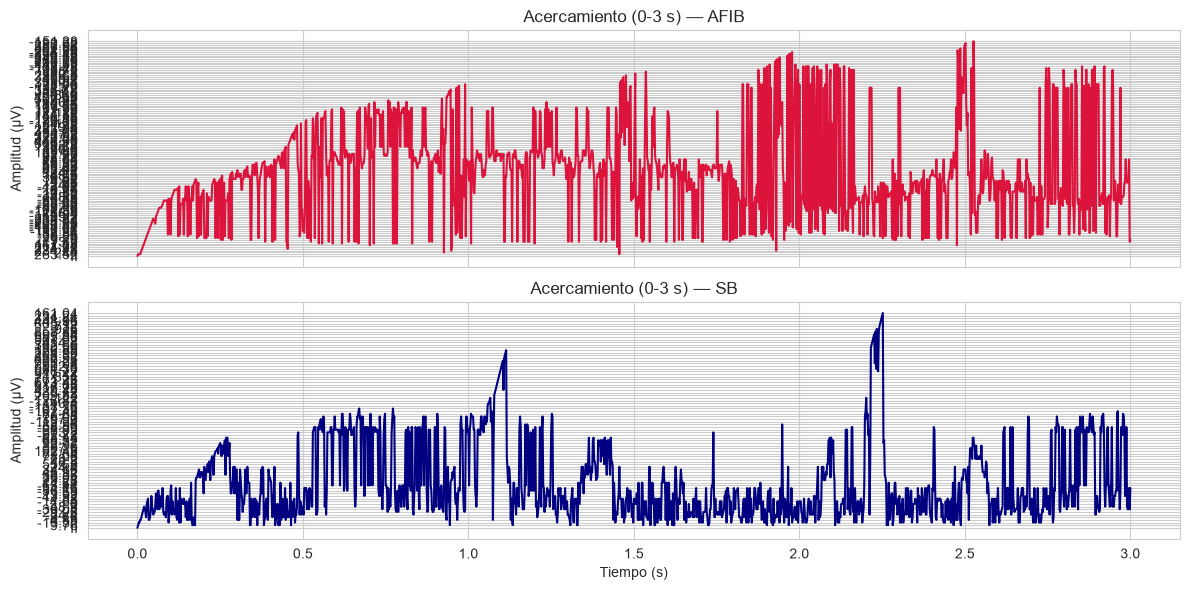

In [29]:
zoom = (t >= 0) & (t <= 3)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t[zoom], sig_A[zoom, lead_idx], color="crimson")
axs[0].set_title(f"Acercamiento (0-3 s) — {rhythm_A}")
axs[0].set_ylabel("Amplitud (µV)")

axs[1].plot(t[zoom], sig_B[zoom, lead_idx], color="navy")
axs[1].set_title(f"Acercamiento (0-3 s) — {rhythm_B}")
axs[1].set_ylabel("Amplitud (µV)")
axs[1].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()

### 2.4 Detección de picos R, frecuencia cardiaca y regularidad

In [32]:
def detect_r_peaks(signal, fs, min_rr_s=0.3):
    """Detección simple de picos R por umbral adaptativo y distancia mínima entre picos."""
    # Si el array contiene texto, reemplazamos comas por puntos antes de convertir a float
    if signal.dtype == object or isinstance(signal.flat[0], str):
        signal = np.array([str(val).replace(',', '.') for val in signal], dtype=float)
    else:
        signal = np.asarray(signal, dtype=float)
    
    height = np.mean(signal) + 2 * np.std(signal)
    peaks, _ = find_peaks(signal, height=height, distance=int(min_rr_s * fs))
    return peaks

peaks_A = detect_r_peaks(sig_A[:, lead_idx], fs)
peaks_B = detect_r_peaks(sig_B[:, lead_idx], fs)

rr_A = np.diff(peaks_A) / fs   # intervalos R-R en segundos
rr_B = np.diff(peaks_B) / fs

hr_A = 60 / rr_A                # frecuencia cardiaca instantánea (lpm)
hr_B = 60 / rr_B

print(f"{rhythm_A} ({label_A}):")
print(f"  Picos R detectados : {len(peaks_A)}")
print(f"  FC promedio        : {hr_A.mean():.1f} lpm")
print(f"  Desv. estándar RR  : {rr_A.std()*1000:.1f} ms  (mayor valor = más irregular)")
print()
print(f"{rhythm_B} ({label_B}):")
print(f"  Picos R detectados : {len(peaks_B)}")
print(f"  FC promedio        : {hr_B.mean():.1f} lpm")
print(f"  Desv. estándar RR  : {rr_B.std()*1000:.1f} ms  (mayor valor = más irregular)")

ValueError: could not convert string to float: 'II'

NameError: name 'peaks_A' is not defined

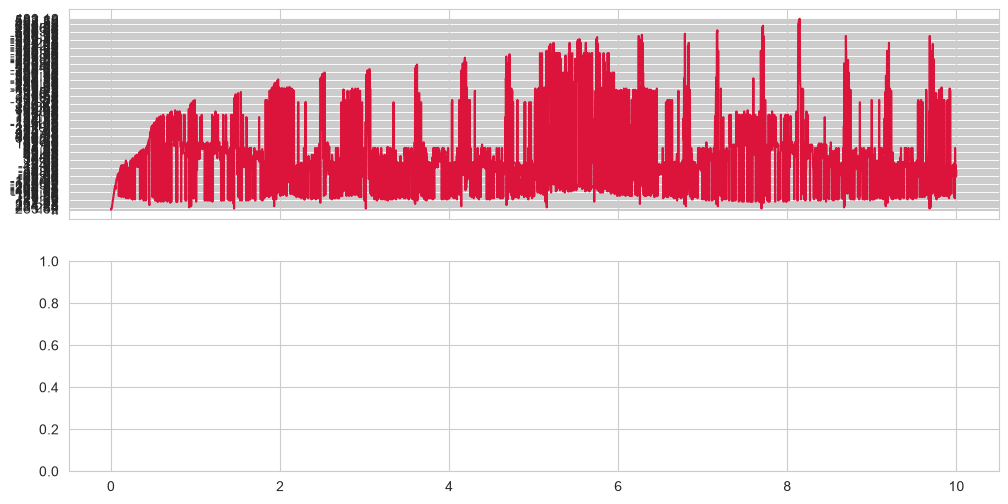

In [33]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t, sig_A[:, lead_idx], color="crimson")
axs[0].plot(t[peaks_A], sig_A[peaks_A, lead_idx], "ko", label="Picos R")
axs[0].set_title(f"Detección de picos R — {rhythm_A}")
axs[0].legend()

axs[1].plot(t, sig_B[:, lead_idx], color="navy")
axs[1].plot(t[peaks_B], sig_B[peaks_B, lead_idx], "ko", label="Picos R")
axs[1].set_title(f"Detección de picos R — {rhythm_B}")
axs[1].set_xlabel("Tiempo (s)")
axs[1].legend()

plt.tight_layout()
plt.show()

### 2.5 Análisis comparativo

**Morfología.** En el registro de bradicardia sinusal (SB) se observan ondas P claramente definidas y de morfología constante antes de cada complejo QRS, consistente con un origen sinusal del ritmo. En el registro de fibrilación auricular (AFIB) no es posible identificar ondas P discretas; en su lugar, la línea de base entre complejos QRS muestra una ondulación irregular de baja amplitud (ondas f).

**Amplitud.** La amplitud del complejo QRS es, en general, comparable entre ambos registros (dominada por la despolarización ventricular), pero conviene revisar visualmente la escala vertical de cada gráfica, ya que puede variar entre sujetos por diferencias anatómicas o de impedancia de contacto de los electrodos.

**Frecuencia cardiaca.** La frecuencia obtenida a partir de los intervalos R-R confirma la definición clínica de cada ritmo: en SB se espera un valor por debajo de 60 lpm, mientras que en AFIB la frecuencia ventricular puede variar ampliamente (dependiendo del grado de conducción a través del nodo AV) y tiende a mostrar mayor dispersión latido a latido.

**Regularidad.** La desviación estándar de los intervalos R-R es notablemente mayor en el registro de AFIB que en el de SB, lo que refleja de forma cuantitativa la irregularidad característica de la fibrilación auricular frente a la regularidad de un ritmo sinusal (aunque sea lento, como en la bradicardia).

## Conclusiones parciales

- ChapmanECG es una base de datos grande, balanceada en cuanto a duración y frecuencia de muestreo entre registros (10 s, 500 Hz, 12 derivaciones), pero fuertemente desbalanceada en el número de registros por clase de ritmo.
- La comparación visual y cuantitativa (picos R, intervalos R-R) entre un registro de fibrilación auricular y uno de bradicardia sinusal evidencia diferencias claras en morfología (presencia/ausencia de onda P), frecuencia cardiaca y regularidad del ritmo, coherentes con la fisiopatología de cada arritmia.
- Estas observaciones motivan el análisis estadístico formal (puntos 3 y 4 de la guía) para determinar si las diferencias observadas entre grupos son estadísticamente significativas.